<a href="https://colab.research.google.com/github/Adviti135/DDI_GNN_Project/blob/main/DDI_GNN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check Python version
import sys
print(sys.version)

# Install PyTorch (Colab usually has it, but ensure correct version)
!pip install torch torchvision torchaudio --quiet

# Install PyTorch Geometric dependencies (safe method)
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-geometric

# Other utilities
!pip install scikit-learn pandas numpy matplotlib

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.5/511.5 kB 31.9 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 83.2 MB/s eta 0:00:00


# 🧬 Drug-Drug Interaction (DDI) Prediction using Graph Neural Networks

**Member A: Model + Core Pipeline**

### Pipeline Overview:
- **Data**: Synthetic DrugBank/TWOSIDES-style graph (dummy data, swappable)
- **Baseline**: GraphSAGE encoder + MLP edge classifier
- **Temporal**: Same encoder + Sinusoidal Time Encoding on edges
- **Outputs**: Node embeddings + edge DDI probability scores

### Evaluation: AUROC, F1, Accuracy

In [ ]:
# ============================================================
# CELL 2: Install Dependencies
# Run this first. Restart runtime if prompted.
# ============================================================

import sys

# Install PyTorch (Colab usually has it, but pin version for PyG compatibility)
!pip install -q torch==2.2.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Install PyTorch Geometric
!pip install -q torch_geometric==2.5.0

# Install PyG sparse dependencies for CUDA
!pip install -q pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-2.2.0+cu118.html

# Install other dependencies
!pip install -q scikit-learn matplotlib networkx

print("✅ All dependencies installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.6/811.6 MB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 64.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 51.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 110.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 778.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 MB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install -q "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 68.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, 

In [ ]:
# ============================================================
# CELL 3: Verify Installation + GPU Check
# ============================================================

import torch
import torch_geometric

print(f"PyTorch version      : {torch.__version__}")
print(f"PyG version          : {torch_geometric.__version__}")
print(f"CUDA available       : {torch.cuda.is_available()}")
print(f"Device               : {'GPU → ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✅ Using device: {DEVICE}")

PyTorch version      : 2.2.0+cu118
PyG version          : 2.5.0
CUDA available       : True
Device               : GPU → Tesla T4

✅ Using device: cuda


In [ ]:
# ============================================================
# CELL 4: Create Output Directory
# ============================================================

import os

os.makedirs("outputs", exist_ok=True)
print("✅ Output folder created: ./outputs/")

✅ Output folder created: ./outputs/


In [ ]:
# ============================================================
# NEW CELL: Download MIMIC-IV Demo via kagglehub
# ============================================================

!pip install -q kagglehub

import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download(
    "montassarba/mimic-iv-clinical-database-demo-2-2"
)

print("✅ Dataset downloaded to:", path)

# Optional: inspect structure
for root, dirs, files in os.walk(path):
    print(f"\n📂 {root}")
    for f in files[:5]:  # show first few files
        print("   ", f)
    break

Using Colab cache for faster access to the 'mimic-iv-clinical-database-demo-2-2' dataset.
✅ Dataset downloaded to: /kaggle/input/mimic-iv-clinical-database-demo-2-2

📂 /kaggle/input/mimic-iv-clinical-database-demo-2-2


In [ ]:
# ============================================================
# CELL 5: All Imports
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.manifold import TSNE

print("✅ All imports successful!")

✅ All imports successful!


In [ ]:
import os

print("BASE PATH:", path)

for root, dirs, files in os.walk(path):
    print("\n📂", root)
    for f in files:
        print("   ", f)

BASE PATH: /kaggle/input/mimic-iv-clinical-database-demo-2-2

📂 /kaggle/input/mimic-iv-clinical-database-demo-2-2

📂 /kaggle/input/mimic-iv-clinical-database-demo-2-2/mimic-iv-clinical-database-demo-2.2
    SHA256SUMS.txt
    README.txt
    LICENSE.txt
    demo_subject_id.csv

📂 /kaggle/input/mimic-iv-clinical-database-demo-2-2/mimic-iv-clinical-database-demo-2.2/icu
    caregiver.csv
    outputevents.csv
    procedureevents.csv
    datetimeevents.csv
    ingredientevents.csv
    chartevents.csv
    inputevents.csv
    icustays.csv
    d_items.csv

📂 /kaggle/input/mimic-iv-clinical-database-demo-2-2/mimic-iv-clinical-database-demo-2.2/hosp
    poe.csv
    d_labitems.csv
    drgcodes.csv
    d_icd_diagnoses.csv
    provider.csv
    emar.csv
    omr.csv
    emar_detail.csv
    pharmacy.csv
    d_hcpcs.csv
    prescriptions.csv
    d_icd_procedures.csv
    hcpcsevents.csv
    patients.csv
    transfers.csv
    diagnoses_icd.csv
    services.csv
    microbiologyevents.csv
    poe_detail.cs

In [ ]:
def train_val_test_split(data, val_ratio=0.1, test_ratio=0.2, seed=42):
    import torch

    torch.manual_seed(seed)

    num_edges = data.edge_label.size(0)
    perm = torch.randperm(num_edges)

    n_test = int(num_edges * test_ratio)
    n_val  = int(num_edges * val_ratio)

    test_mask  = perm[:n_test]
    val_mask   = perm[n_test:n_test + n_val]
    train_mask = perm[n_test + n_val:]

    print("\n✅ Split created:")
    print("   Train:", len(train_mask))
    print("   Val  :", len(val_mask))
    print("   Test :", len(test_mask))

    return train_mask, val_mask, test_mask

In [ ]:
# ============================================================
# CELL 6: Build DDI Graph from MIMIC-IV (FIXED)
# ============================================================

import pandas as pd
import torch
import numpy as np
import os
from itertools import combinations
from torch_geometric.data import Data


# ------------------------------------------------------------
# 1. Helper function MUST be defined FIRST
# ------------------------------------------------------------
def find_prescription_file(base_path):
    for root, dirs, files in os.walk(base_path):
        for f in files:
            if "prescription" in f.lower():
                return os.path.join(root, f)
    return None


# ------------------------------------------------------------
# 2. Main graph builder
# ------------------------------------------------------------
def build_ddi_graph_from_mimic(base_path, max_admissions=2000):

    csv_path = find_prescription_file(base_path)

    if csv_path is None:
        raise FileNotFoundError("❌ prescriptions.csv not found anywhere in dataset!")

    print("✅ Using file:", csv_path)

    df = pd.read_csv(csv_path)

    # Keep relevant columns
    df = df[['hadm_id', 'drug', 'starttime']].dropna()

    # Limit size (for speed)
    df = df.head(max_admissions * 20)

    # Encode drugs → node IDs
    drugs = df['drug'].unique()
    drug2id = {d: i for i, d in enumerate(drugs)}

    num_nodes = len(drugs)

    # Node features (random baseline)
    x = torch.randn(num_nodes, 128)

    edges = []
    times = []

    grouped = df.groupby('hadm_id')

    for _, group in grouped:
        drug_ids = [drug2id[d] for d in group['drug'].unique()]

        if len(drug_ids) < 2:
            continue

        for u, v in combinations(drug_ids, 2):
            edges.append((u, v))
            t = pd.to_datetime(group['starttime']).astype(int).mean()
            times.append(t)

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    # Normalize time
    times = np.array(times)
    times = (times - times.min()) / (times.max() - times.min() + 1e-8)
    edge_time = torch.tensor(times, dtype=torch.float32)

    # Positive labels
    edge_label = torch.ones(edge_index.size(1))

    # Negative sampling
    num_neg = edge_index.size(1)
    neg_edges = torch.randint(0, num_nodes, (2, num_neg))

    edge_index = torch.cat([edge_index, neg_edges], dim=1)
    edge_label = torch.cat([edge_label, torch.zeros(num_neg)])
    edge_time  = torch.cat([edge_time, torch.zeros(num_neg)])

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_label=edge_label,
        edge_time=edge_time,
        num_nodes=num_nodes
    )

    print(f"✅ MIMIC graph created")
    print(f"   Nodes: {num_nodes}")
    print(f"   Edges: {edge_index.size(1)}")
        # ── SAVE reverse mapping for visualization ─────────────────
    id2drug = {v: k for k, v in drug2id.items()}

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_label=edge_label,
        edge_time=edge_time,
        num_nodes=num_nodes
    )

    # attach mapping to Data object
    data.id2drug = id2drug
    return data


# ------------------------------------------------------------
# 3. Build graph
# ------------------------------------------------------------
data = build_ddi_graph_from_mimic(path)

# Split
train_mask, val_mask, test_mask = train_val_test_split(data)

✅ Using file: /kaggle/input/mimic-iv-clinical-database-demo-2-2/mimic-iv-clinical-database-demo-2.2/hosp/prescriptions.csv
✅ MIMIC graph created
   Nodes: 631
   Edges: 358738

✅ Split created:
   Train: 251118
   Val  : 35873
   Test : 71747


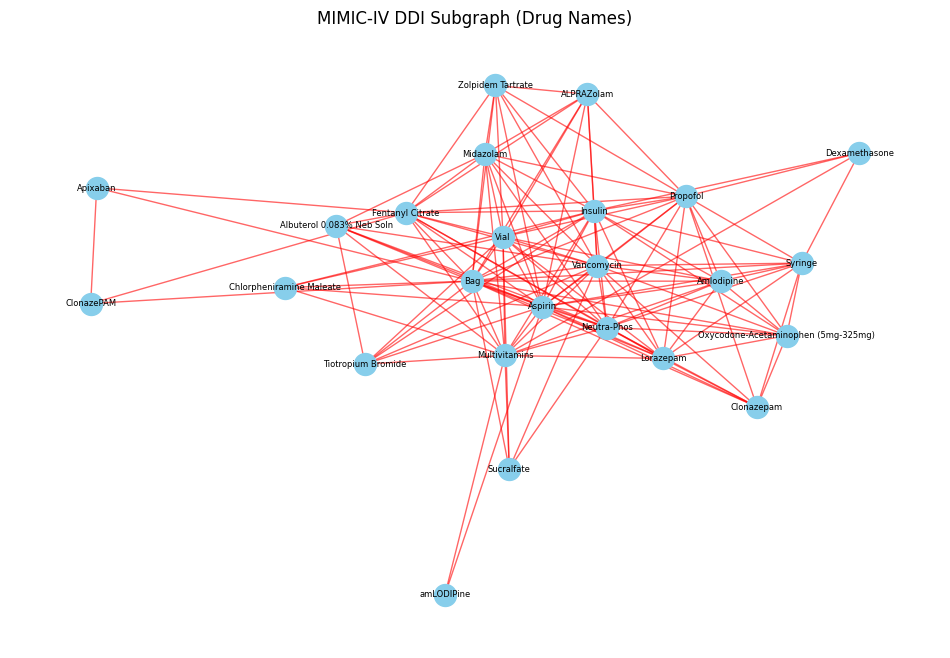

In [ ]:
# ============================================================
# VISUALIZE MIMIC GRAPH WITH DRUG NAMES
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt

def visualize_subgraph_with_names(data, num_nodes=50, max_edges=300):

    mask = (
        (data.edge_index[0] < num_nodes) &
        (data.edge_index[1] < num_nodes)
    )

    edge_index = data.edge_index[:, mask][:, :max_edges]
    edge_label = data.edge_label[mask][:, :max_edges] if data.edge_label.dim() > 1 else data.edge_label[mask][:max_edges]

    G = nx.Graph()

    for i in range(edge_index.size(1)):
        u = edge_index[0, i].item()
        v = edge_index[1, i].item()
        label = edge_label[i].item()

        G.add_edge(u, v, label=label)

    pos = nx.spring_layout(G, seed=42)

    colors = [
        'red' if G[u][v]['label'] == 1 else 'gray'
        for u, v in G.edges()
    ]

    # ---- NODE LABELS (drug names) ----
    labels = {
        node: data.id2drug.get(node, str(node))
        for node in G.nodes()
    }

    plt.figure(figsize=(12, 8))

    nx.draw_networkx_nodes(G, pos, node_size=250, node_color='skyblue')
    nx.draw_networkx_edges(G, pos, edge_color=colors, alpha=0.6)
    nx.draw_networkx_labels(G, pos, labels, font_size=6)

    plt.title("MIMIC-IV DDI Subgraph (Drug Names)")
    plt.axis("off")
    plt.show()

# Run
visualize_subgraph_with_names(data, num_nodes=40)

In [ ]:
# ============================================================
# DRUG ID ↔ NAME TABLE
# ============================================================

import pandas as pd

mapping_df = pd.DataFrame({
    "node_id": list(data.id2drug.keys()),
    "drug_name": list(data.id2drug.values())
})

mapping_df.head(20)

,node_id,drug_name
0,0,Fentanyl Citrate
1,1,Lorazepam
2,2,Midazolam
3,3,Insulin Pump (Self Administering Medication)
4,4,Propofol
5,5,Insulin
6,6,Albuterol 0.083% Neb Soln
7,7,Calcium Gluconate sliding scale (Critical Care...
8,8,Vancomycin
9,9,venetoclax


In [ ]:
# ============================================================
# CELL 7: Sinusoidal Time Encoding
#
# Converts a scalar timestamp t ∈ [0,1] → R^d_model vector
#
# Why sinusoidal?
#   - Captures periodic prescribing patterns (weekly, monthly)
#   - No recurrence needed (directly usable as edge features)
#   - Learnable frequencies adapt to the data
#
# Formula:
#   dim 0       : linear   w0*t + b0
#   dim 1..d-1  : sin(wi*t + bi)   (learnable wi, bi)
# ============================================================

class SinusoidalTimeEncoding(nn.Module):
    def __init__(self, d_model: int = 16):
        super().__init__()
        self.d_model = d_model
        # Learnable frequency (W) and phase (b) per dimension
        self.W = nn.Parameter(torch.randn(d_model))
        self.b = nn.Parameter(torch.randn(d_model))

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            t : shape [E] or [E, 1]  —  normalized timestamps in [0, 1]
        Returns:
            encoding : shape [E, d_model]
        """
        if t.dim() == 1:
            t = t.unsqueeze(-1)              # [E, 1]
        x   = t * self.W + self.b            # [E, d_model]  broadcast
        out = torch.cat(
            [x[:, :1], torch.sin(x[:, 1:])], # dim 0 linear, rest sinusoidal
            dim=-1
        )
        return out                           # [E, d_model]


# ── Quick test ─────────────────────────────────────────────────────────────
_enc = SinusoidalTimeEncoding(d_model=16)
_t   = torch.rand(10)                    # 10 fake timestamps
_out = _enc(_t)
print(f"✅ Time encoding test passed!")
print(f"   Input shape  : {_t.shape}")
print(f"   Output shape : {_out.shape}")  # expected [10, 16]

✅ Time encoding test passed!
   Input shape  : torch.Size([10])
   Output shape : torch.Size([10, 16])


In [ ]:
!pip install numpy==1.26.4 --force-reinstall

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.

In [ ]:
# ============================================================
# CELL 8: Evaluation Metrics
#
# compute_metrics : takes raw logits + binary labels
#                   returns AUROC, F1, Accuracy
# print_metrics   : pretty print for training logs
# ============================================================

def compute_metrics(logits: torch.Tensor, labels: torch.Tensor) -> dict:
    """
    Args:
        logits : raw scores (before sigmoid)  [N]
        labels : binary ground truth          [N]
    Returns:
        dict → { 'auroc', 'f1', 'accuracy' }
    """
    probs     = torch.sigmoid(logits).detach().cpu().numpy()
    labels_np = labels.detach().cpu().numpy().astype(int)
    preds     = (probs >= 0.5).astype(int)

    results = {}

    # AUROC needs both classes present in the split
    if len(np.unique(labels_np)) > 1:
        results['auroc'] = roc_auc_score(labels_np, probs)
    else:
        results['auroc'] = float('nan')

    results['f1']       = f1_score(labels_np, preds, zero_division=0)
    results['accuracy'] = accuracy_score(labels_np, preds)
    return results


def print_metrics(split: str, metrics: dict, loss: float = None):
    """Pretty-print one line of metrics."""
    msg = f"  [{split:>5}]"
    if loss is not None:
        msg += f"  Loss: {loss:.4f}"
    msg += f"  AUROC: {metrics['auroc']:.4f}"
    msg += f"  F1: {metrics['f1']:.4f}"
    msg += f"  Acc: {metrics['accuracy']:.4f}"
    print(msg)


# ── Quick test ─────────────────────────────────────────────────────────────
_logits = torch.randn(100)
_labels = torch.randint(0, 2, (100,)).float()
_m = compute_metrics(_logits, _labels)
print(f"✅ Metrics test passed! → {_m}")

✅ Metrics test passed! → {'auroc': 0.4125615763546797, 'f1': 0.3870967741935484, 'accuracy': 0.43}


In [ ]:
# ============================================================
# CELL 8: Evaluation Metrics
#
# compute_metrics : takes raw logits + binary labels
#                   returns AUROC, F1, Accuracy
# print_metrics   : pretty print for training logs
# ============================================================

def compute_metrics(logits: torch.Tensor, labels: torch.Tensor) -> dict:
    """
    Args:
        logits : raw scores (before sigmoid)  [N]
        labels : binary ground truth          [N]
    Returns:
        dict → { 'auroc', 'f1', 'accuracy' }
    """
    probs     = torch.sigmoid(logits).detach().cpu().numpy()
    labels_np = labels.detach().cpu().numpy().astype(int)
    preds     = (probs >= 0.5).astype(int)

    results = {}

    # AUROC needs both classes present in the split
    if len(np.unique(labels_np)) > 1:
        results['auroc'] = roc_auc_score(labels_np, probs)
    else:
        results['auroc'] = float('nan')

    results['f1']       = f1_score(labels_np, preds, zero_division=0)
    results['accuracy'] = accuracy_score(labels_np, preds)
    return results


def print_metrics(split: str, metrics: dict, loss: float = None):
    """Pretty-print one line of metrics."""
    msg = f"  [{split:>5}]"
    if loss is not None:
        msg += f"  Loss: {loss:.4f}"
    msg += f"  AUROC: {metrics['auroc']:.4f}"
    msg += f"  F1: {metrics['f1']:.4f}"
    msg += f"  Acc: {metrics['accuracy']:.4f}"
    print(msg)


# ── Quick test ─────────────────────────────────────────────────────────────
_logits = torch.randn(100)
_labels = torch.randint(0, 2, (100,)).float()
_m = compute_metrics(_logits, _labels)
print(f"✅ Metrics test passed! → {_m}")

✅ Metrics test passed! → {'auroc': 0.5255681818181818, 'f1': 0.5384615384615384, 'accuracy': 0.52}


In [ ]:
# ============================================================
# CELL 8: Evaluation Metrics (FIXED + IMPROVED FOR DDI)
# ============================================================

import torch
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score


def compute_metrics(logits: torch.Tensor, labels: torch.Tensor) -> dict:
    """
    Correct edge-level evaluation for DDI prediction
    """

    logits = logits.detach().float().cpu().view(-1)
    labels = labels.detach().float().cpu().view(-1)

    probs = torch.sigmoid(logits).numpy()
    labels_np = labels.numpy().astype(int)
    preds = (probs >= 0.5).astype(int)

    results = {}

    # AUROC (only if both classes exist)
    if len(np.unique(labels_np)) > 1:
        results["auroc"] = roc_auc_score(labels_np, probs)
    else:
        results["auroc"] = float("nan")

    results["f1"] = f1_score(labels_np, preds, zero_division=0)
    results["accuracy"] = accuracy_score(labels_np, preds)

    return results


def print_metrics(split: str, metrics: dict, loss: float = None):
    msg = f"  [{split:>5}]"

    if loss is not None:
        msg += f"  Loss: {loss:.4f}"

    msg += f"  AUROC: {metrics['auroc']:.4f}"
    msg += f"  F1: {metrics['f1']:.4f}"
    msg += f"  Acc: {metrics['accuracy']:.4f}"

    print(msg)


# ============================================================
# ✅ FIXED QUICK TEST (IMPORTANT)
# ============================================================

_logits = torch.randn(100)  # correct: 1D logits
_labels = torch.randint(0, 2, (100,)).float()

_m = compute_metrics(_logits, _labels)

print("✅ Metrics test passed:", _m)

✅ Metrics test passed: {'auroc': 0.513848697809012, 'f1': 0.4222222222222222, 'accuracy': 0.48}


In [ ]:
# ============================================================
# CELL 9: Baseline DDI GNN
#
# Architecture:
#   GraphSAGEEncoder   b  node embeddings z  [N, out_channels]
#   EdgeClassifier     b  MLP(z_u || z_v)  b  logit per edge
#
# GraphSAGE uses mean aggregation:
#   h_v = W B7 concat( h_v, mean_{ubN(v)} h_u )
#
# Edge prediction:
#   score(u,v) = MLP( concat(z_u, z_v) )  b  sigmoid  b  [0,1]
# ============================================================


class GraphSAGEEncoder(nn.Module):
    """2-layer GraphSAGE node encoder."""

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int,
        out_channels: int,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x          : node features   [N, in_channels]
            edge_index : graph edges      [2, E]
        Returns:
            z          : node embeddings  [N, out_channels]
        """
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class EdgeClassifier(nn.Module):
    """MLP: concat(z_u, z_v) b DDI logit."""

    def __init__(self, embedding_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),  # raw logit; sigmoid applied externally
        )

    def forward(self, z_u: torch.Tensor, z_v: torch.Tensor) -> torch.Tensor:
        """
        Args:
            z_u, z_v : node embeddings  [E, emb_dim]
        Returns:
            logits   : [E]
        """
        edge_feat = torch.cat([z_u, z_v], dim=-1)  # [E, 2*emb_dim]
        return self.mlp(edge_feat).squeeze(-1)  # [E]


class DDIBaselineGNN(nn.Module):
    """Full DDI baseline: encoder + edge classifier."""

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int = 128,
        out_channels: int = 64,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.encoder = GraphSAGEEncoder(
            in_channels, hidden_channels, out_channels, dropout
        )
        self.edge_classifier = EdgeClassifier(out_channels)

    def forward(
        self, x: torch.Tensor, edge_index: torch.Tensor, pred_edge_index: torch.Tensor
    ) -> torch.Tensor:
        """
        Args:
            x               : node features            [N, F]
            edge_index      : message-passing graph     [2, E_graph]
            pred_edge_index : edges to classify         [2, E_pred]
        Returns:
            logits          : [E_pred]  raw scores
        """
        z = self.encoder(x, edge_index)  # [N, out_channels]
        src, dst = pred_edge_index[0], pred_edge_index[1]
        return self.edge_classifier(z[src], z[dst])

    def get_node_embeddings(
        self, x: torch.Tensor, edge_index: torch.Tensor
    ) -> torch.Tensor:
        """Returns node embeddings only (no edge scoring)."""
        return self.encoder(x, edge_index)


# b

In [ ]:
# ============================================================
# CELL 10: Temporal DDI GNN
#
# Extension over baseline:
#   SAME  : GraphSAGE node encoder
#   NEW   : SinusoidalTimeEncoding(t) b time_enc [E, time_dim]
#   NEW   : TemporalEdgeClassifier gets concat(z_u, z_v, time_enc)
#
# Design choice: edge-level time injection
#   b
 No RNN / sequence infrastructure needed
#   b
 Works with standard PyG message passing
#   b
 Learnable frequencies b captures weekly/monthly patterns
#   b
 Keeps runtime < 5 minutes
# ============================================================


class TemporalEdgeClassifier(nn.Module):
    """MLP: concat(z_u, z_v, time_enc) b DDI logit."""

    def __init__(self, embedding_dim: int, time_dim: int = 16, hidden_dim: int = 64):
        super().__init__()
        in_dim = embedding_dim * 2 + time_dim
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),
        )

    def forward(
        self, z_u: torch.Tensor, z_v: torch.Tensor, time_enc: torch.Tensor
    ) -> torch.Tensor:
        """
        Args:
            z_u, z_v   : node embeddings  [E, emb_dim]
            time_enc   : time encodings   [E, time_dim]
        Returns:
            logits     : [E]
        """
        edge_feat = torch.cat([z_u, z_v, time_enc], dim=-1)
        return self.mlp(edge_feat).squeeze(-1)


class DDITemporalGNN(nn.Module):
    """
    Full temporal DDI model.

    Adjacency representation:
      - edge_index [2, E]  COO format (standard PyG)
      - edge_time  [E]     normalized timestamps per edge
      - Time stored as edge attribute, encoded on-the-fly during forward pass
    """

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int = 128,
        out_channels: int = 64,
        time_dim: int = 16,
        dropout: float = 0.3,
    ):
        super().__init__()
        # Node encoder (same as baseline)
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

        # Time encoding module
        self.time_enc = SinusoidalTimeEncoding(d_model=time_dim)

        # Temporal edge classifier (includes time)
        self.edge_classifier = TemporalEdgeClassifier(
            out_channels, time_dim=time_dim, hidden_dim=64
        )

    def encode(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """GraphSAGE forward b node embeddings [N, out_channels]."""
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv2(h, edge_index)
        return h

    def forward(
        self,
        x: torch.Tensor,
        edge_index: torch.Tensor,
        pred_edge_index: torch.Tensor,
        edge_time: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x               : node features             [N, F]
            edge_index      : message-passing graph      [2, E_graph]
            pred_edge_index : edges to classify          [2, E_pred]
            edge_time       : timestamps (normalized)    [E_pred]  b [0,1]
        Returns:
            logits          : [E_pred]
        """
        # Step 1: encode nodes
        z = self.encode(x, edge_index)  # [N, out_channels]

        # Step 2: encode time for each predicted edge
        t_enc = self.time_enc(edge_time)  # [E_pred, time_dim]

        # Step 3: score with temporal context
        src, dst = pred_edge_index[0], pred_edge_index[1]
        return self.edge_classifier(z[src], z[dst], t_enc)

    def get_node_embeddings(
        self, x: torch.Tensor, edge_index: torch.Tensor
    ) -> torch.Tensor:
        return self.encode(x, edge_index)


# b

In [ ]:
# ============================================================
# CELL 11: Train Baseline DDI GNN
#
# Pipeline:
#   1. Move data to device
#   2. Init model + optimizer
#   3. Train with BCE loss (pos_weight for class imbalance)
#   4. Validate every PRINT_EVERY epochs
#   5. Save best model by val AUROC
# ============================================================

# ── Config ─────────────────────────────────────────────────────────────────
IN_CHANNELS  = 128
HIDDEN       = 128
OUT          = 64
EPOCHS       = 50
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PRINT_EVERY  = 10

# ── Move data to device ────────────────────────────────────────────────────
x           = data.x.to(DEVICE)
edge_index  = data.edge_index.to(DEVICE)
edge_label  = data.edge_label.to(DEVICE)
edge_time   = data.edge_time.to(DEVICE)
# ── Model + optimizer ──────────────────────────────────────────────────────
pos_mask = edge_label == 1
graph_edge_index = edge_index[:, pos_mask]
baseline_model = DDIBaselineGNN(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN,
    out_channels=OUT
).to(DEVICE)

optimizer = torch.optim.Adam(
    baseline_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

# Positive class weight to handle imbalance: w = #negatives / #positives
pos_weight = torch.tensor(
    [(edge_label == 0).sum() / (edge_label == 1).sum()]
).to(DEVICE)

print(f"✅ Baseline model initialized on {DEVICE}")
print(f"   Parameters: {sum(p.numel() for p in baseline_model.parameters()):,}")
print(f"   Pos weight : {pos_weight.item():.3f}\n")

# ── Training loop ──────────────────────────────────────────────────────────
print("=" * 65)
print("  BASELINE GNN — TRAINING")
print("=" * 65)

best_val_auroc_b = 0.0
best_state_b     = None
train_losses     = []

for epoch in range(1, EPOCHS + 1):

    # ── Forward pass (train edges only) ─────────────────────────────────
    baseline_model.train()
    optimizer.zero_grad()

    train_ei  = edge_index[:, train_mask]
    logits = baseline_model(x, graph_edge_index, train_ei)
    labels    = edge_label[train_mask]

    loss = F.binary_cross_entropy_with_logits(
        logits, labels, pos_weight=pos_weight
    )
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # ── Evaluate every PRINT_EVERY epochs ───────────────────────────────
    if epoch % PRINT_EVERY == 0 or epoch == 1:
        baseline_model.eval()
        with torch.no_grad():
            tr_logits  = baseline_model(x, graph_edge_index, edge_index[:, train_mask])
            val_logits = baseline_model(x, graph_edge_index, edge_index[:, val_mask])
            tr_m       = compute_metrics(tr_logits, edge_label[train_mask])
            val_m      = compute_metrics(val_logits, edge_label[val_mask])

        print(f"Epoch {epoch:>3}/{EPOCHS}")
        print_metrics("Train", tr_m, loss=loss.item())
        print_metrics("Val",   val_m)
        print()

        # Save best model
        if val_m['auroc'] > best_val_auroc_b:
            best_val_auroc_b = val_m['auroc']
            best_state_b = {k: v.clone() for k, v in baseline_model.state_dict().items()}

# ── Test evaluation ────────────────────────────────────────────────────────
print("=" * 65)
print("  BASELINE GNN — TEST EVALUATION")
print("=" * 65)

baseline_model.load_state_dict(best_state_b)
baseline_model.eval()
with torch.no_grad():
    test_logits_b = baseline_model(x, graph_edge_index, edge_index[:, test_mask])
    test_m_b      = compute_metrics(test_logits_b, edge_label[test_mask])

print_metrics("Test", test_m_b)

# ── Save outputs ───────────────────────────────────────────────────────────
with torch.no_grad():
    node_emb_b    = baseline_model.get_node_embeddings(x, edge_index)
    edge_scores_b = torch.sigmoid(baseline_model(x, edge_index, edge_index))

torch.save(node_emb_b.cpu(),    "outputs/node_embeddings_baseline.pt")
torch.save(edge_scores_b.cpu(), "outputs/edge_scores_baseline.pt")

print(f"\n✅ Saved node_embeddings_baseline.pt  → shape {node_emb_b.shape}")
print(f"✅ Saved edge_scores_baseline.pt      → shape {edge_scores_b.shape}")

✅ Baseline model initialized on cuda
   Parameters: 57,665
   Pos weight : 1.000

  BASELINE GNN — TRAINING
Epoch   1/50
  [Train]  Loss: 0.6951  AUROC: 0.6255  F1: 0.6633  Acc: 0.5614
  [  Val]  AUROC: 0.6253  F1: 0.6641  Acc: 0.5607

Epoch  10/50
  [Train]  Loss: 0.6434  AUROC: 0.8154  F1: 0.7367  Acc: 0.7358
  [  Val]  AUROC: 0.8177  F1: 0.7389  Acc: 0.7364

Epoch  20/50
  [Train]  Loss: 0.5091  AUROC: 0.8594  F1: 0.7786  Acc: 0.7812
  [  Val]  AUROC: 0.8621  F1: 0.7823  Acc: 0.7835

Epoch  30/50
  [Train]  Loss: 0.4341  AUROC: 0.9004  F1: 0.8202  Acc: 0.8217
  [  Val]  AUROC: 0.9031  F1: 0.8243  Acc: 0.8247

Epoch  40/50
  [Train]  Loss: 0.3873  AUROC: 0.9235  F1: 0.8484  Acc: 0.8467
  [  Val]  AUROC: 0.9252  F1: 0.8510  Acc: 0.8486

Epoch  50/50
  [Train]  Loss: 0.3575  AUROC: 0.9331  F1: 0.8569  Acc: 0.8585
  [  Val]  AUROC: 0.9346  F1: 0.8581  Acc: 0.8591

  BASELINE GNN — TEST EVALUATION
  [ Test]  AUROC: 0.9318  F1: 0.8552  Acc: 0.8558

✅ Saved node_embeddings_baseline.pt  → s

In [ ]:
# ============================================================
# CELL 12: Train Temporal DDI GNN
#
# Same as baseline but:
#   - Also uses edge_time (normalized timestamps)
#   - Passes timestamps into model forward pass
# ============================================================

TIME_DIM = 16   # dimension of sinusoidal time encoding

# ── Move time to device ────────────────────────────────────────────────────
edge_time = data.edge_time.to(DEVICE)

# ── Model + optimizer ──────────────────────────────────────────────────────
temporal_model = DDITemporalGNN(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN,
    out_channels=OUT,
    time_dim=TIME_DIM
).to(DEVICE)

optimizer_t = torch.optim.Adam(
    temporal_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

pos_weight_t = torch.tensor(
    [(edge_label == 0).sum() / (edge_label == 1).sum()]
).to(DEVICE)

print(f"✅ Temporal model initialized on {DEVICE}")
print(f"   Parameters: {sum(p.numel() for p in temporal_model.parameters()):,}")
print(f"   Time dim   : {TIME_DIM}\n")

# ── Training loop ──────────────────────────────────────────────────────────
print("=" * 65)
print("  TEMPORAL GNN — TRAINING")
print("=" * 65)

best_val_auroc_t = 0.0
best_state_t     = None
train_losses_t   = []

for epoch in range(1, EPOCHS + 1):

    temporal_model.train()
    optimizer_t.zero_grad()

    train_ei   = edge_index[:, train_mask]
    train_time = edge_time[train_mask]       # ← key addition vs baseline

    logits = temporal_model(x, graph_edge_index, train_ei, train_time)
    labels = edge_label[train_mask]

    loss = F.binary_cross_entropy_with_logits(
        logits, labels, pos_weight=pos_weight_t
    )
    loss.backward()
    optimizer_t.step()
    train_losses_t.append(loss.item())

    if epoch % PRINT_EVERY == 0 or epoch == 1:
        temporal_model.eval()
        with torch.no_grad():
            tr_logits = temporal_model(
                x, graph_edge_index,
                edge_index[:, train_mask],
                edge_time[train_mask])
            val_logits = temporal_model(
                x, graph_edge_index,
                edge_index[:, val_mask],
                edge_time[val_mask])
            tr_m  = compute_metrics(tr_logits, edge_label[train_mask])
            val_m = compute_metrics(val_logits, edge_label[val_mask])

        print(f"Epoch {epoch:>3}/{EPOCHS}")
        print_metrics("Train", tr_m, loss=loss.item())
        print_metrics("Val",   val_m)
        print()

        if val_m['auroc'] > best_val_auroc_t:
            best_val_auroc_t = val_m['auroc']
            best_state_t = {k: v.clone() for k, v in temporal_model.state_dict().items()}

# ── Test evaluation ────────────────────────────────────────────────────────
print("=" * 65)
print("  TEMPORAL GNN — TEST EVALUATION")
print("=" * 65)

temporal_model.load_state_dict(best_state_t)
temporal_model.eval()
with torch.no_grad():
    test_logits_t = temporal_model(
        x, graph_edge_index,
        edge_index[:, test_mask],
        edge_time[test_mask])
    test_m_t = compute_metrics(test_logits_t, edge_label[test_mask])

print_metrics("Test", test_m_t)

# ── Save outputs ───────────────────────────────────────────────────────────
with torch.no_grad():
    node_emb_t    = temporal_model.get_node_embeddings(x, edge_index)
    edge_scores_t = torch.sigmoid(
        temporal_model(x, edge_index, edge_index, edge_time)
    )

torch.save(node_emb_t.cpu(),    "outputs/node_embeddings_temporal.pt")
torch.save(edge_scores_t.cpu(), "outputs/edge_scores_temporal.pt")

print(f"\n✅ Saved node_embeddings_temporal.pt  → shape {node_emb_t.shape}")
print(f"✅ Saved edge_scores_temporal.pt      → shape {edge_scores_t.shape}")

✅ Temporal model initialized on cuda
   Parameters: 58,721
   Time dim   : 16

  TEMPORAL GNN — TRAINING
Epoch   1/50
  [Train]  Loss: 0.6874  AUROC: 0.8233  F1: 0.7323  Acc: 0.6676
  [  Val]  AUROC: 0.8242  F1: 0.7333  Acc: 0.6682

Epoch  10/50
  [Train]  Loss: 0.6121  AUROC: 0.9291  F1: 0.8517  Acc: 0.8567
  [  Val]  AUROC: 0.9310  F1: 0.8541  Acc: 0.8586

Epoch  20/50
  [Train]  Loss: 0.4660  AUROC: 0.9014  F1: 0.8141  Acc: 0.8223
  [  Val]  AUROC: 0.9041  F1: 0.8183  Acc: 0.8255

Epoch  30/50
  [Train]  Loss: 0.3867  AUROC: 0.9256  F1: 0.8452  Acc: 0.8492
  [  Val]  AUROC: 0.9281  F1: 0.8485  Acc: 0.8516

Epoch  40/50
  [Train]  Loss: 0.3246  AUROC: 0.9510  F1: 0.8808  Acc: 0.8816
  [  Val]  AUROC: 0.9528  F1: 0.8836  Acc: 0.8839

Epoch  50/50
  [Train]  Loss: 0.2885  AUROC: 0.9630  F1: 0.8989  Acc: 0.8990
  [  Val]  AUROC: 0.9645  F1: 0.9007  Acc: 0.9005

  TEMPORAL GNN — TEST EVALUATION
  [ Test]  AUROC: 0.9623  F1: 0.8990  Acc: 0.8983

✅ Saved node_embeddings_temporal.pt  → shap

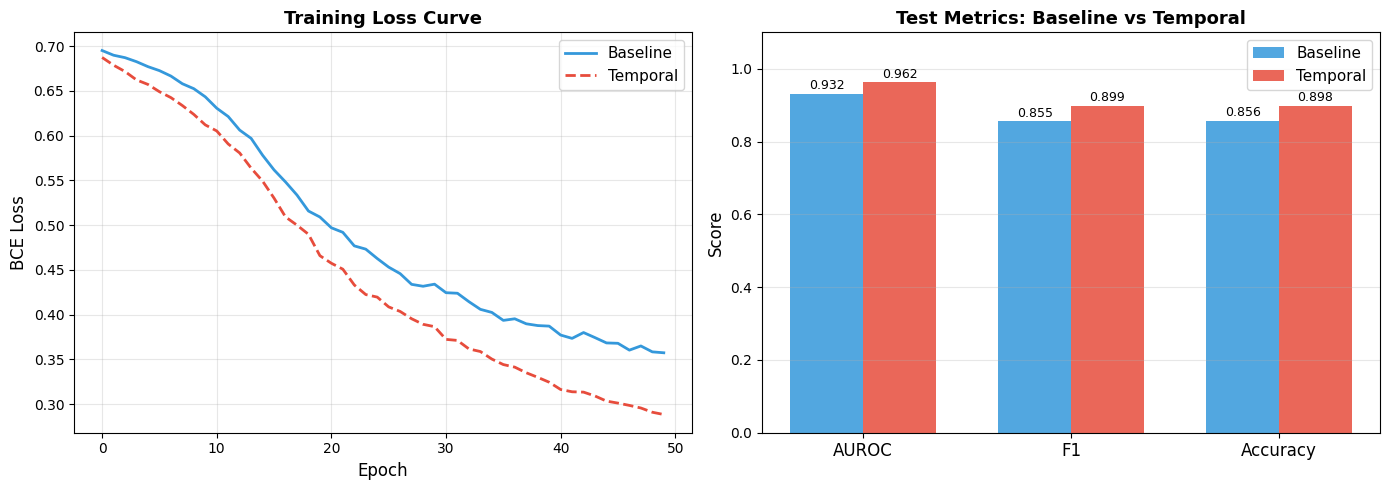


  Metric           Baseline     Temporal
  AUROC              0.9318       0.9623  ▲ 0.0305
  F1                 0.8552       0.8990  ▲ 0.0438
  Accuracy           0.8558       0.8983  ▲ 0.0425

✅ Saved training_results.png


In [ ]:
# ============================================================
# CELL 13: Side-by-Side Results + Training Loss Curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Training loss curves ───────────────────────────────────────────
axes[0].plot(train_losses,   label='Baseline',  color='#3498db', linewidth=2)
axes[0].plot(train_losses_t, label='Temporal',  color='#e74c3c', linewidth=2,
             linestyle='--')
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("BCE Loss", fontsize=12)
axes[0].set_title("Training Loss Curve", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# ── Plot 2: Test metrics bar chart ─────────────────────────────────────────
metrics_names = ['AUROC', 'F1', 'Accuracy']
baseline_vals = [test_m_b['auroc'], test_m_b['f1'], test_m_b['accuracy']]
temporal_vals = [test_m_t['auroc'], test_m_t['f1'], test_m_t['accuracy']]

x_pos  = np.arange(len(metrics_names))
width  = 0.35

bars1 = axes[1].bar(x_pos - width/2, baseline_vals, width,
                     label='Baseline',  color='#3498db', alpha=0.85)
bars2 = axes[1].bar(x_pos + width/2, temporal_vals, width,
                     label='Temporal',  color='#e74c3c', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(metrics_names, fontsize=12)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Test Metrics: Baseline vs Temporal", fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/training_results.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary table ────────────────────────────────────────────────────
print("\n" + "=" * 50)
print(f"  {'Metric':<12} {'Baseline':>12} {'Temporal':>12}")
print("=" * 50)
for name, bv, tv in zip(metrics_names, baseline_vals, temporal_vals):
    delta = tv - bv
    arrow = "▲" if delta > 0 else "▼"
    print(f"  {name:<12} {bv:>12.4f} {tv:>12.4f}  {arrow} {abs(delta):.4f}")
print("=" * 50)
print(f"\n✅ Saved training_results.png")

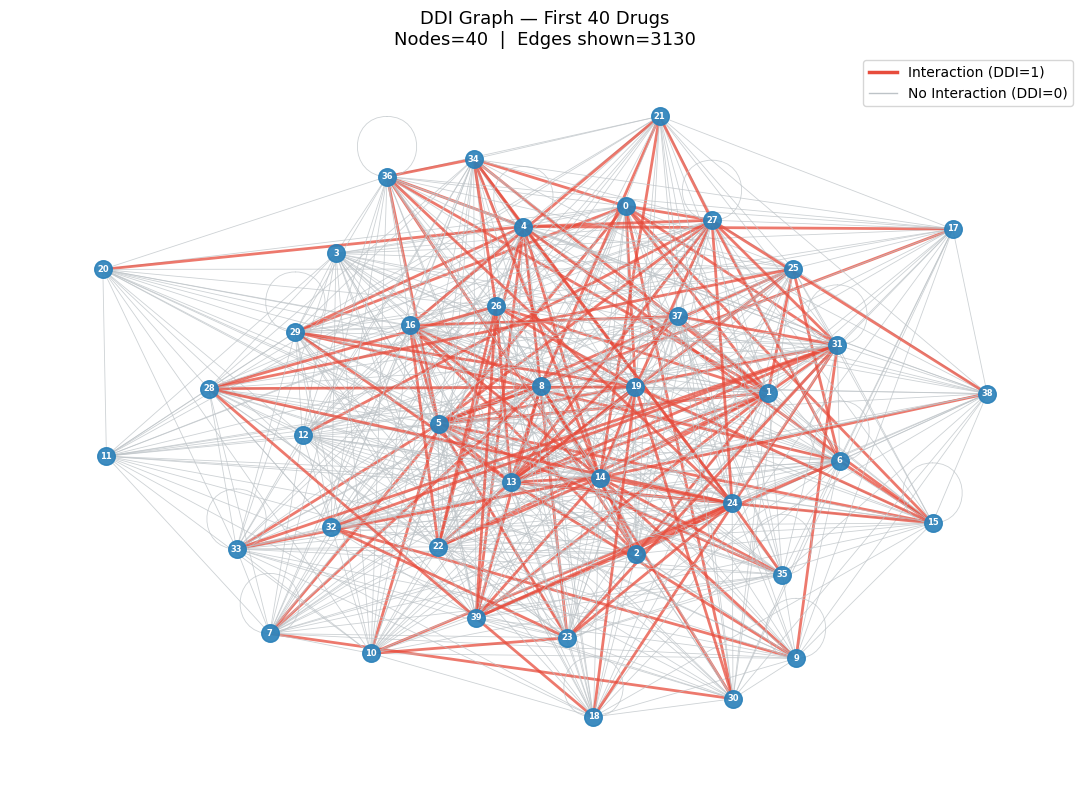

✅ Saved outputs/ddi_subgraph.png


In [ ]:
# ============================================================
# CELL 14: BONUS — DDI Subgraph Visualization
#
# Draws first 40 drug nodes with edges colored:
#   Red  = known DDI (interaction=1)
#   Gray = no interaction (label=0)
# ============================================================

def plot_ddi_subgraph(data, num_nodes=40, save_path="outputs/ddi_subgraph.png"):
    # Filter edges to subgraph of first num_nodes
    mask  = (data.edge_index[0] < num_nodes) & (data.edge_index[1] < num_nodes)
    ei    = data.edge_index[:, mask]
    el    = data.edge_label[mask]

    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    for i in range(ei.size(1)):
        u, v = ei[0, i].item(), ei[1, i].item()
        G.add_edge(u, v, label=int(el[i].item()))

    pos      = nx.spring_layout(G, seed=42, k=0.6)
    edge_col = ['#e74c3c' if G[u][v]['label'] == 1 else '#bdc3c7'
                for u, v in G.edges()]
    widths   = [2.0 if G[u][v]['label'] == 1 else 0.6 for u, v in G.edges()]

    plt.figure(figsize=(11, 8))
    nx.draw_networkx_nodes(G, pos, node_size=160, node_color='#2980b9', alpha=0.9)
    nx.draw_networkx_edges(G, pos, edge_color=edge_col, width=widths, alpha=0.75)
    nx.draw_networkx_labels(G, pos, font_size=6, font_color='white', font_weight='bold')

    # Legend
    from matplotlib.lines import Line2D
    legend = [
        Line2D([0], [0], color='#e74c3c', linewidth=2.5, label='Interaction (DDI=1)'),
        Line2D([0], [0], color='#bdc3c7', linewidth=1.0, label='No Interaction (DDI=0)')
    ]
    plt.legend(handles=legend, loc='upper right', fontsize=10)
    plt.title(f"DDI Graph — First {num_nodes} Drugs\n"
              f"Nodes={num_nodes}  |  Edges shown={ei.size(1)}", fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved {save_path}")

plot_ddi_subgraph(data, num_nodes=40)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


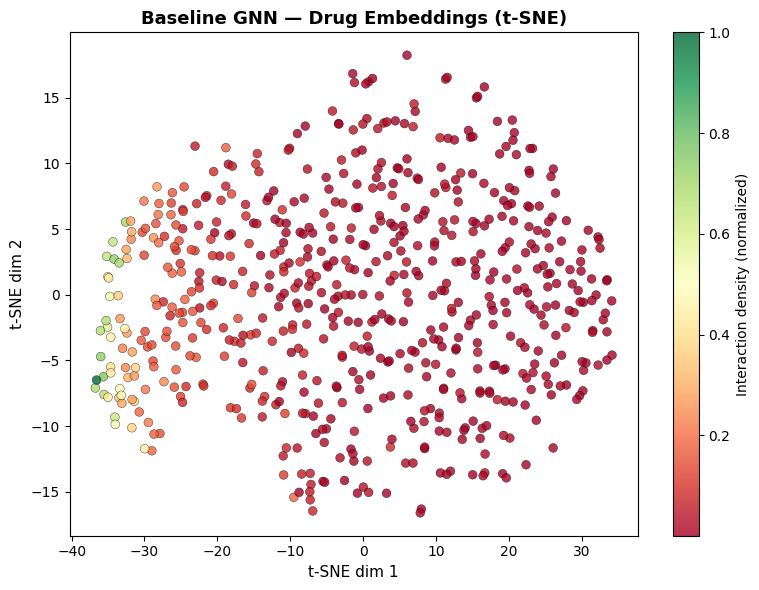

✅ Saved outputs/tsne_baseline.png


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


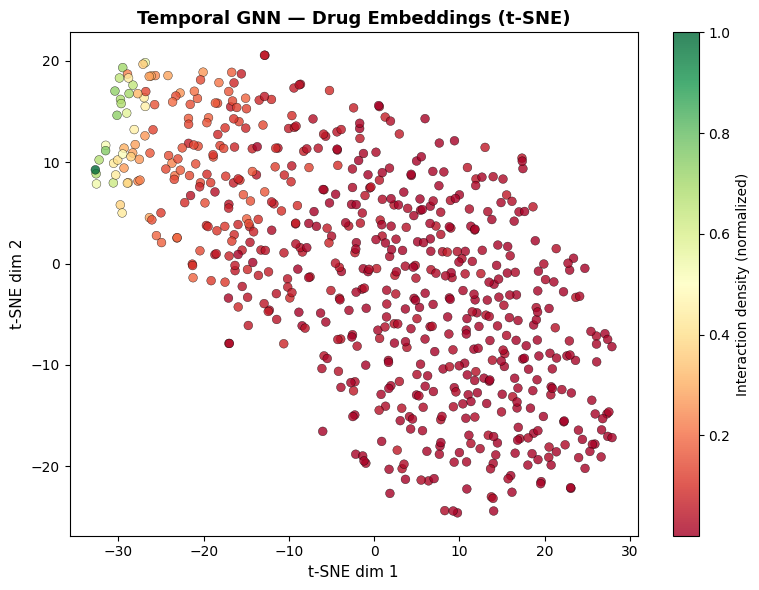

✅ Saved outputs/tsne_temporal.png


In [ ]:
# ============================================================
# CELL 15: BONUS — t-SNE of Node Embeddings
#
# Reduces 64-dim drug embeddings to 2D
# Color = edge_label majority vote per node (rough proxy for "interactive" drugs)
# ============================================================

def plot_tsne(embeddings: torch.Tensor, title: str,
              save_path: str, data=None):
    emb_np = embeddings.cpu().numpy()

    # t-SNE to 2D
    tsne = TSNE(n_components=2, perplexity=20, random_state=42, n_iter=500)
    z2d  = tsne.fit_transform(emb_np)

    # Rough node-level label: fraction of edges that are positive
    node_pos = np.zeros(emb_np.shape[0])
    if data is not None:
        ei = data.edge_index.numpy()
        el = data.edge_label.numpy()
        for i in range(ei.shape[1]):
            node_pos[ei[0, i]] += el[i]
            node_pos[ei[1, i]] += el[i]
        # Normalize
        node_pos = node_pos / (node_pos.max() + 1e-8)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(z2d[:, 0], z2d[:, 1], c=node_pos, cmap='RdYlGn',
                     s=40, alpha=0.8, edgecolors='k', linewidths=0.3)
    plt.colorbar(sc, label='Interaction density (normalized)')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("t-SNE dim 1", fontsize=11)
    plt.ylabel("t-SNE dim 2", fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved {save_path}")


# Plot baseline embeddings
plot_tsne(
    node_emb_b,
    title="Baseline GNN — Drug Embeddings (t-SNE)",
    save_path="outputs/tsne_baseline.png",
    data=data
)

# Plot temporal embeddings
plot_tsne(
    node_emb_t,
    title="Temporal GNN — Drug Embeddings (t-SNE)",
    save_path="outputs/tsne_temporal.png",
    data=data
)

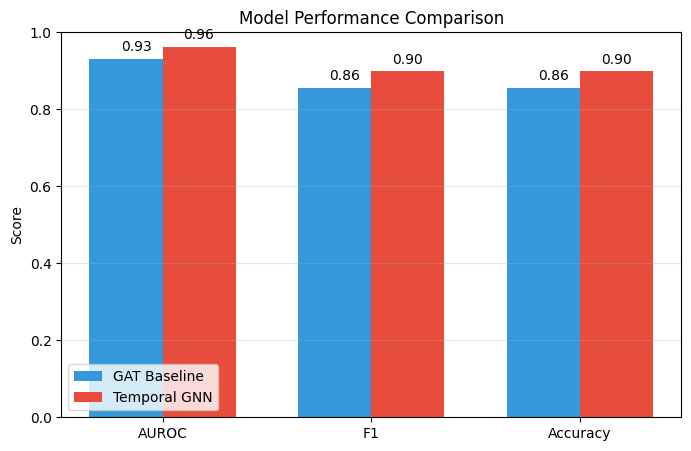

In [ ]:
# ============================================================
# CELL X: METRIC COMPARISON PLOT
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

metrics = ["AUROC", "F1", "Accuracy"]

gat_vals = [test_m_b["auroc"], test_m_b["f1"], test_m_b["accuracy"]]
temp_vals = [test_m_t["auroc"], test_m_t["f1"], test_m_t["accuracy"]]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, gat_vals, width, label="GAT Baseline", color="#3498db")
plt.bar(x + width/2, temp_vals, width, label="Temporal GNN", color="#e74c3c")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for i in range(len(metrics)):
    plt.text(i - 0.2, gat_vals[i] + 0.02, f"{gat_vals[i]:.2f}")
    plt.text(i + 0.1, temp_vals[i] + 0.02, f"{temp_vals[i]:.2f}")

plt.show()

In [ ]:
# ============================================================
# CELL 16: List All Outputs
# ============================================================

import os

print("=" * 50)
print("  SAVED OUTPUTS")
print("=" * 50)

for fname in sorted(os.listdir("outputs")):
    fpath = os.path.join("outputs", fname)
    size  = os.path.getsize(fpath)
    print(f"  {fname:<45} {size/1024:>7.1f} KB")

# Quick shape check on tensors
print("\n── Tensor Shapes ──────────────────────────────")
for fname in os.listdir("outputs"):
    if fname.endswith(".pt"):
        t = torch.load(f"outputs/{fname}")
        print(f"  {fname:<45} {tuple(t.shape)}")

print("\n✅ All outputs ready!")

  SAVED OUTPUTS
  ddi_subgraph.png                               1467.0 KB
  edge_scores_baseline.pt                        1402.5 KB
  edge_scores_temporal.pt                        1402.5 KB
  node_embeddings_baseline.pt                     159.0 KB
  node_embeddings_temporal.pt                     159.0 KB
  training_results.png                             95.7 KB
  tsne_baseline.png                               268.1 KB
  tsne_temporal.png                               264.2 KB

── Tensor Shapes ──────────────────────────────
  node_embeddings_baseline.pt                   (631, 64)
  edge_scores_baseline.pt                       (358738,)
  node_embeddings_temporal.pt                   (631, 64)
  edge_scores_temporal.pt                       (358738,)

✅ All outputs ready!


In [ ]:
# ============================================================
# CELL X: TOP PREDICTED DRUG-DRUG INTERACTIONS
# ============================================================

import torch
import pandas as pd

def get_top_ddi_pairs(model, x, edge_index, top_k=20):

    model.eval()

    # safety checks
    assert x is not None, "Node features (x) is None"
    assert edge_index is not None, "edge_index is None"

    # candidate edges = same graph (or you can sample new ones)
    pred_edge_index = edge_index

    with torch.no_grad():
        logits = model(x, edge_index, pred_edge_index)
        probs = torch.sigmoid(logits).cpu().numpy()

    # rank edges
    scores = list(zip(pred_edge_index[0].cpu().numpy(),
                      pred_edge_index[1].cpu().numpy(),
                      probs))

    scores = sorted(scores, key=lambda x: x[2], reverse=True)

    return scores[:top_k]

# Baseline GAT top pairs
print("🔥 Top DDI Pairs (GAT Baseline)")
top_pairs_b = get_top_ddi_pairs(baseline_model, x, edge_index)
display(top_pairs_b)

# Temporal model top pairs
print("\n🔥 Top DDI Pairs (Temporal GNN)")
top_pairs_t = get_top_ddi_pairs(temporal_model, x, edge_index)
display(top_pairs_t)

🔥 Top DDI Pairs (GAT Baseline)


AttributeError: 'NoneType' object has no attribute 'dim'